In [1]:
import json
import sqlite3
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

In [2]:
def process_sqlite_report_kernel_only(filePath):
    con = sqlite3.connect(filePath)
    con.row_factory = sqlite3.Row 
    cur = con.cursor()
    query = """
    SELECT
        'kernel' AS activity_type,
        names.value AS name,
        k.start,
        k.end,
        k.end - k.start AS duration,
        k.registersPerThread,
        k.gridX, k.gridY, k.gridZ,
        k.blockX, k.blockY, k.blockZ,
        k.staticSharedMemory, k.dynamicSharedMemory,
        k.localMemoryPerThread, k.localMemoryTotal,
        k.sharedMemoryLimitConfig,
        k.streamId,
        k.deviceId,
        NULL AS bytes,
        NULL AS copyKind,
        NULL as srcKind,
        NULL as dstKind,
        NULL AS memKind          -- new column for memset
    FROM CUPTI_ACTIVITY_KIND_KERNEL AS k
    JOIN StringIds AS names ON k.demangledName = names.id
    
    ORDER BY start;
    """

    cur.execute(query)
    rows = [dict(row) for row in cur.fetchall()]
    return rows

In [3]:
data_matrix = process_sqlite_report_kernel_only("build/Linux-x86_64/pool_matching_joint_matrix_fp16.sqlite")

In [4]:
data_normal_fp16 = process_sqlite_report_kernel_only("build_normal/Linux-x86_64/pool_matching_normal_fp16.sqlite")

In [5]:
data_normal_fp32 = process_sqlite_report_kernel_only("build_normal_fp32/Linux-x86_64/pool_matching_normal_fp32.sqlite")

In [6]:
data_matrix[13]

{'activity_type': 'kernel',
 'name': 'Typeinfo name for popsift::Compute_squared_norm',
 'start': 730683475,
 'end': 730686323,
 'duration': 2848,
 'registersPerThread': 16,
 'gridX': 1000,
 'gridY': 1,
 'gridZ': 1,
 'blockX': 32,
 'blockY': 1,
 'blockZ': 1,
 'staticSharedMemory': 0,
 'dynamicSharedMemory': 0,
 'localMemoryPerThread': 0,
 'localMemoryTotal': 42467328,
 'sharedMemoryLimitConfig': 0,
 'streamId': 32,
 'deviceId': 0,
 'bytes': None,
 'copyKind': None,
 'srcKind': None,
 'dstKind': None,
 'memKind': None}

In [7]:
len(data_matrix)

8762

In [8]:
len(data_normal_fp16)

2504

In [9]:
def tensor_replace_names(data):
    pattern = r'\blambda\b'
    for row in data:
        match = re.search(pattern, row["name"])
        if match: 
            row["name"] = "remainder_normal_matching"
        if row["name"] == "Typeinfo name for popsift::Compute_distance_matrix_pre_norm":
            row["name"] = "matrix_matching"
        if row["name"] == "Typeinfo name for popsift::Compute_squared_norm":
            row["name"] = "compute_squared_norm"        

In [10]:
tensor_replace_names(data_matrix)

In [11]:
data_matrix[0]["start"]


723911182

In [12]:
data_matrix[2]["end"]

724382446

In [13]:
(data_matrix[2]["end"] - data_matrix[0]["start"]) / 1000000

0.471264

In [14]:
def tensor_match_time(data):
    start = 0
    # end = 0
    times: list[int] = []
    current_frame = False
    count = 0
    for index, row in enumerate(data):
        if row["name"] == "compute_squared_norm" and not current_frame:
            start = row["start"]
            current_frame = True
        else: 
            current_frame = False
            if index == len(data)- 1:
                count += 1
                if count > 4:
                    times.append(row["end"] - start)
            else:
                if data[index + 1]["name"] == "compute_squared_norm":
                    count += 1
                    if count > 4:
                        times.append(row["end"] - start)
    return times

In [15]:
def normal_match_time(data):
    times: list[int] = []
    for row in data:
        times.append(row["duration"])
    return times

In [27]:
times_matrix =  tensor_match_time(data_matrix)
times_normal = normal_match_time(data_normal_fp16)[4:]
len(times_normal)

2500

In [92]:
def diff(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] - b[i])
    return diff_list
    
def diff_percent(a, b): 
    """a - b (must be same lenght)"""
    diff_list = []
    for i in range(len(a)):
        diff_list.append(100 * (a[i] - b[i]) / b[i])
    return diff_list

def diff_mult(a, b):
    diff_list = []
    for i in range(len(a)):
        diff_list.append(a[i] / b[i])
    return diff_list

In [29]:
times_normal[2499]

1779888591

In [31]:
times_ matrix[2499]

87714868

In [32]:
times_normal[2499] - times_matrix[2499]

1692173723

In [93]:
diff_list = diff(times_normal, times_matrix)
diff_list_p = diff_percent(times_normal, times_matrix)
diff_list_mult = diff_mult(times_normal, times_matrix)

In [34]:
len(diff_list)

2500

In [35]:
data_normal = data_normal_fp16[4:]
len(data_normal)

2500

In [36]:
len(times_matrix)

2500

In [37]:
!pwd

/home/jorgen/personal/thesis/sycl_popsift


In [76]:
times_matrix[:5]

[519009, 973057, 1448545, 1914369, 2389857]

In [77]:
times_normal[:5]

[783461, 1546826, 2831283, 3581657, 3856218]

In [98]:
diff_list_mult[-5:]

[20.57715436764167,
 20.282568876288742,
 20.591241361868175,
 20.570584448608134,
 20.29175476841623]

In [38]:
tensor_meta = pd.read_csv("build/Linux-x86_64/matching_tensor_fp16_metadata.csv")
normal_meta = pd.read_csv("build_normal/Linux-x86_64/matching_normal_fp16_metadata.csv")
normal_fp32_meta = pd.read_csv("build_normal_fp32/Linux-x86_64/matching_normal_fp32_metadata.csv")

In [39]:
print(normal_meta.iloc[0])
print(normal_meta.iloc[0]['matches'])

l_desc_size    2000
r_desc_size    2000
matches         197
Name: 0, dtype: int64
197


In [40]:
def listify(data):
    l = tensor_meta["l_desc_size"].tolist()[4:]
    r = tensor_meta["r_desc_size"].tolist()[4:]
    return l, r

In [41]:
left_desc_len, right_desc_len = listify(tensor_meta)

In [42]:
len(left_desc_len)

2500

In [ ]:
def plot_3d_surface(x, y, z):
    X, Y = np.meshgrid(x, y):
    
    

In [99]:
from scipy.interpolate import griddata

X, Y = np.meshgrid(left_desc_len, right_desc_len)

# Interpolate Z values onto the grid
ms_diff_list = [elm/1000000 for elm in diff_list] # from ns to ms
# diff_list_mult = [elm/100 for elm in diff_list_p]

Z = griddata((left_desc_len, right_desc_len), diff_list_mult, (X, Y), method='linear')

from scipy.ndimage import gaussian_filter

Z_smooth = gaussian_filter(Z, sigma=1)  # Adjust sigma as needed

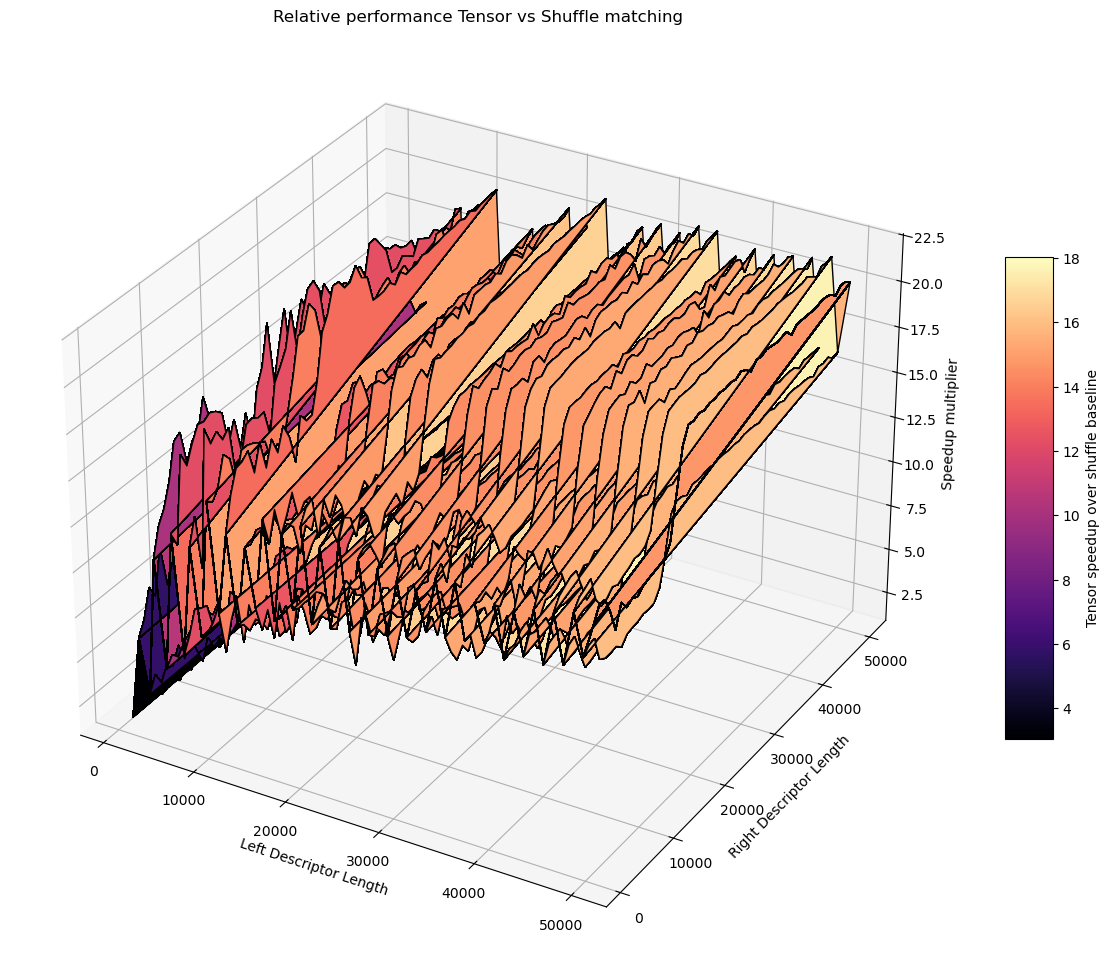

In [100]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot surface
surf = ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='#000')
# surf = ax.plot_surface(X, Y, Z, cmap='magma', edgecolor='#333333')

# Labels
ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_xlabel("Left Descriptor Length")
ax.set_ylabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

# Add color bar
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

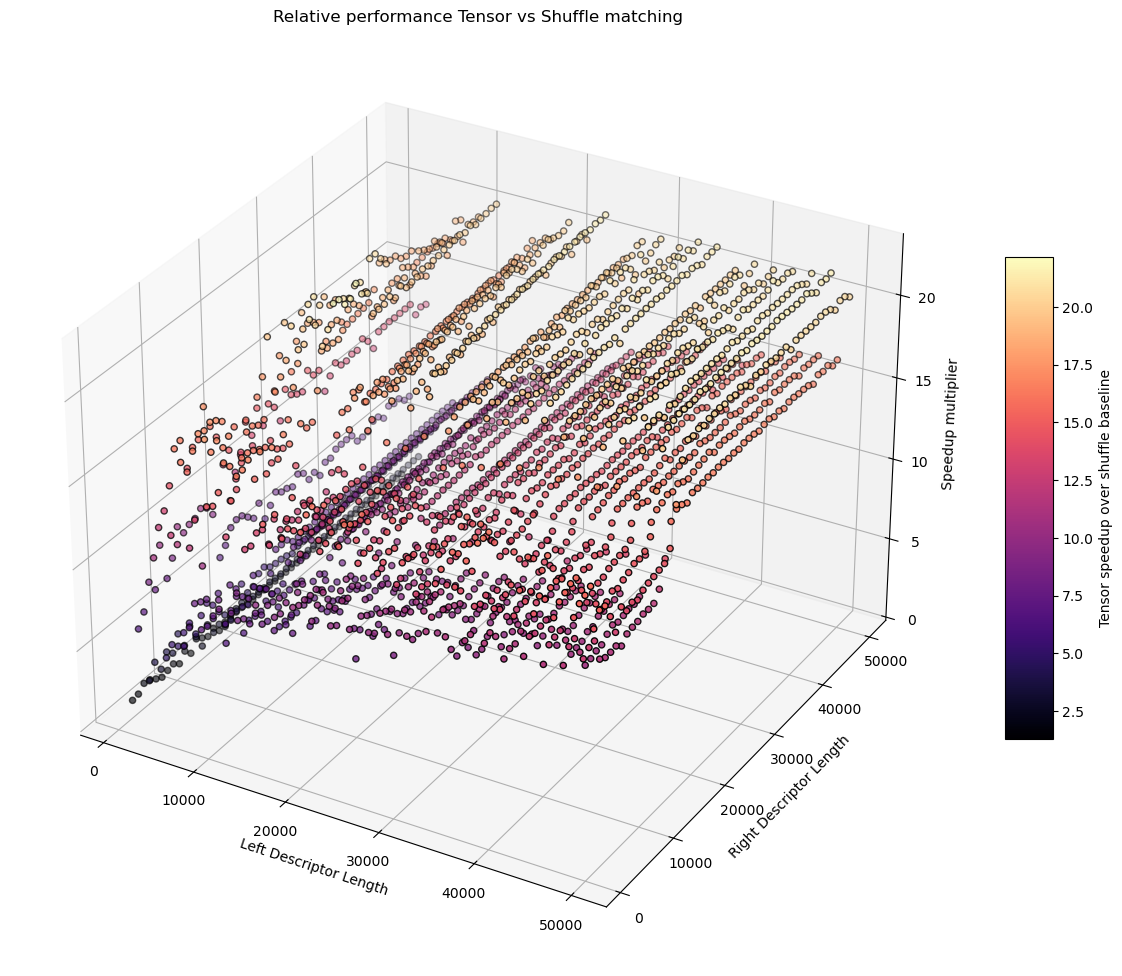

In [101]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(left_desc_len, right_desc_len, diff_list_mult,
           c=diff_list_mult, cmap='magma', edgecolor='k')


ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_xlabel("Left Descriptor Length")
ax.set_ylabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

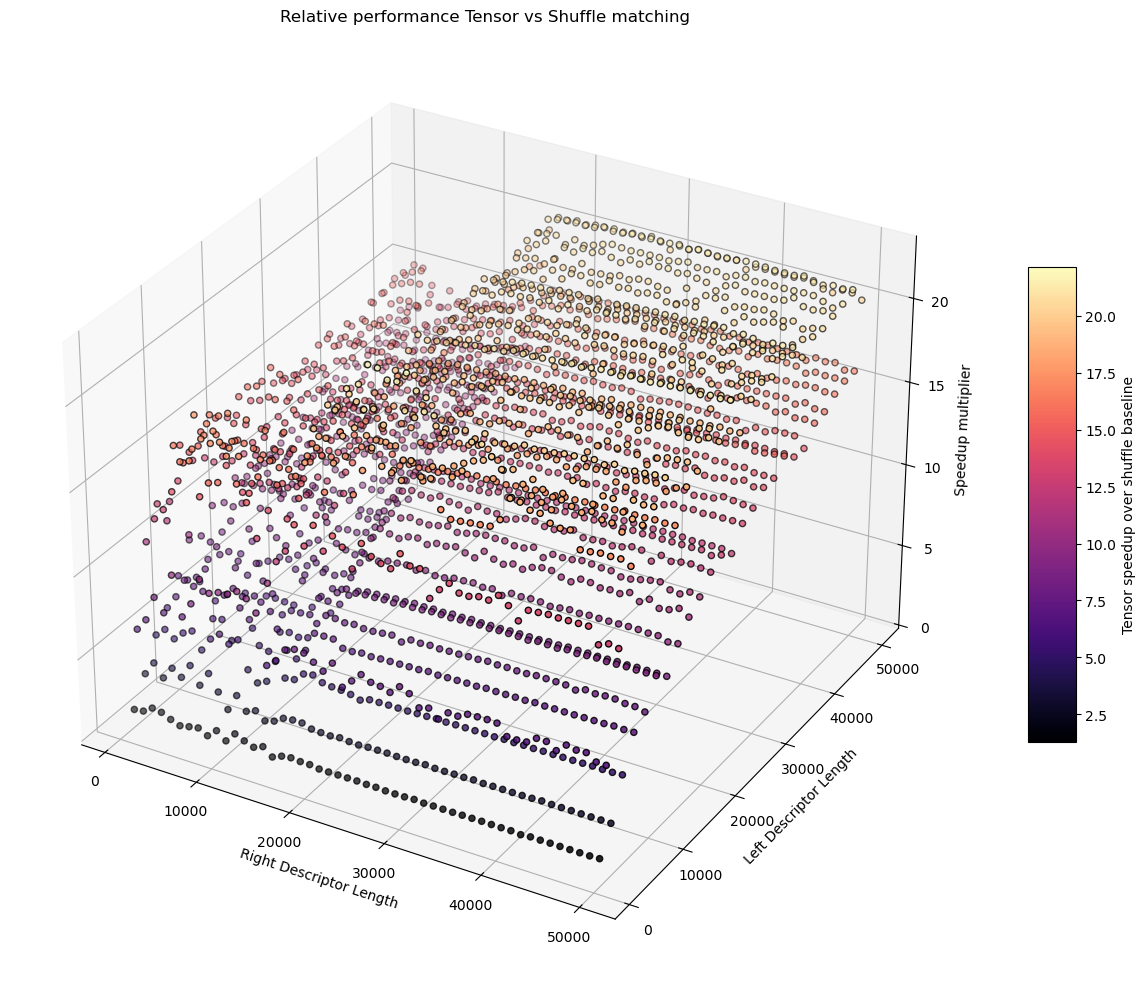

In [102]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(right_desc_len, left_desc_len, diff_list_mult,
           c=diff_list_mult, cmap='magma', edgecolor='k')

ax.set_title("Relative performance Tensor vs Shuffle matching")
ax.set_ylabel("Left Descriptor Length")
ax.set_xlabel("Right Descriptor Length")
ax.set_zlabel("Speedup multiplier")

fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10, label='Tensor speedup over shuffle baseline')
plt.tight_layout()
plt.show()

In [50]:
len(diff_list_mult)

2500

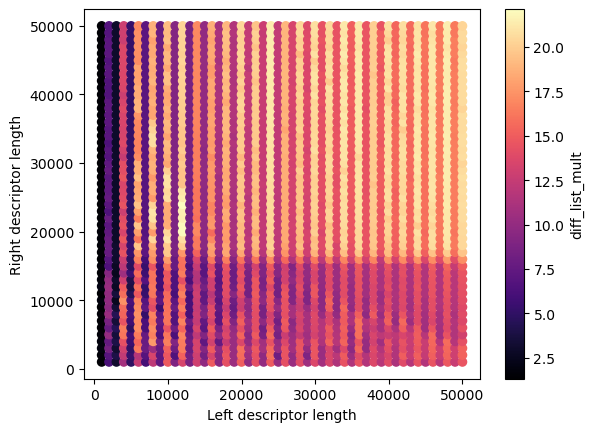

In [104]:

plt.scatter(left_desc_len, right_desc_len, c=diff_list_mult, cmap='magma')
plt.xlabel('Left descriptor length')
plt.ylabel('Right descriptor length')
# plt.title('Raw data (no interpolation)')
plt.colorbar(label='diff_list_mult')
plt.show()

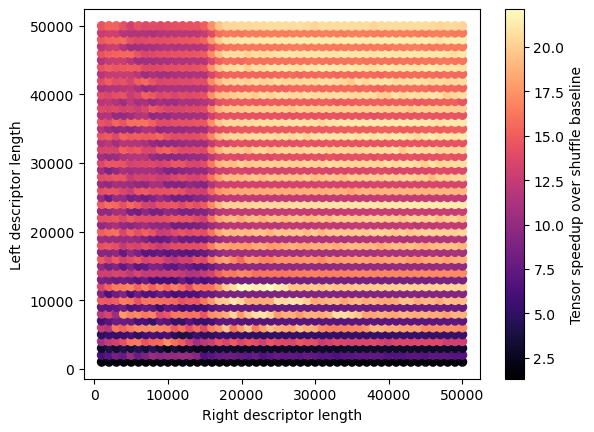

In [105]:

plt.scatter(right_desc_len,left_desc_len,  c=diff_list_mult, cmap='magma')
plt.ylabel('Left descriptor length')
plt.xlabel('Right descriptor length')
# plt.title('Raw data (no interpolation)')
plt.colorbar(label='Tensor speedup over shuffle baseline')
plt.show()

In [106]:
min(diff_list_mult)

1.3104040440652045

In [107]:
max(diff_list_mult)

22.14068151968851

In [ ]:
############################# THE NEW SHIT WITH ZERO TAIL 